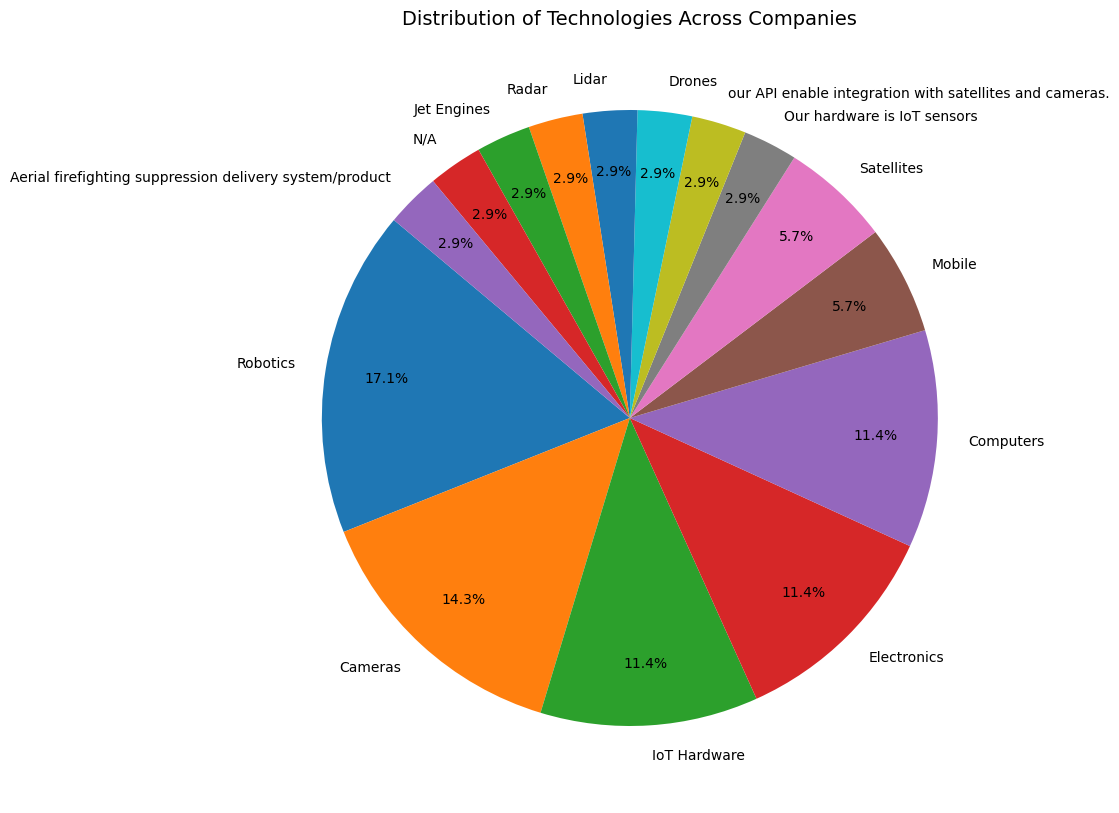

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("Untitled spreadsheet.xlsx")

# Select relevant columns
company_col = "20. Nominate an Innovator -  Company Name   "
tech_col = "31. What Hardware Technologies are Involved in Your Offering(s)? -  (Select all that apply)"

data = df[[company_col, tech_col]].dropna()

# Split multi-select technologies and count
tech_counts = (
    data[tech_col]
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

# Increase figure size
plt.figure(figsize=(10, 10))

plt.pie(
    tech_counts,
    labels=tech_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,   # moves % labels inward
    labeldistance=1.1 # moves text labels outward
)

plt.title("Distribution of Technologies Across Companies", fontsize=14)
plt.show()


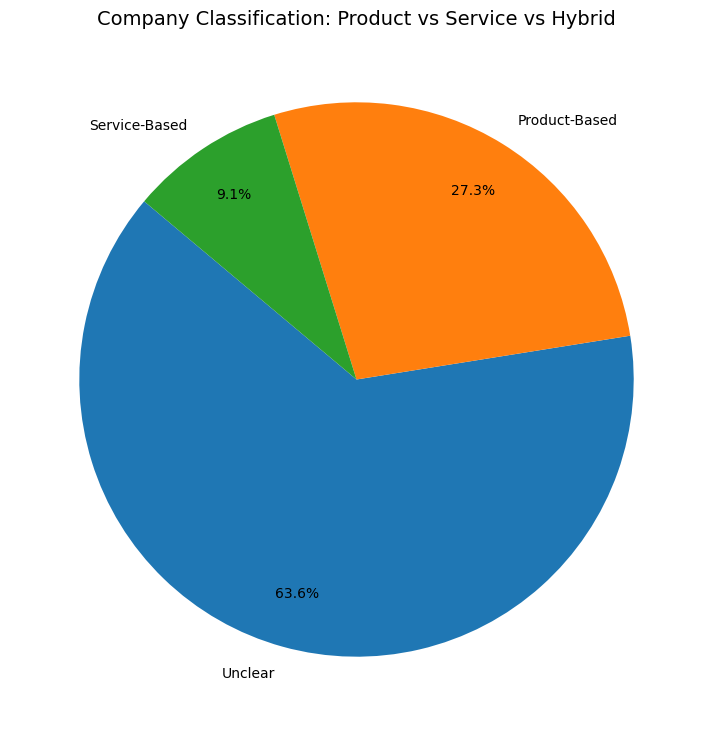

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("Untitled spreadsheet.xlsx")

company_col = "20. Nominate an Innovator -  Company Name   "
desc_col = "21. Nominate an Innovation -  Company's Product and Services   "

data = df[[company_col, desc_col]].dropna()

# Keyword lists
product_keywords = ["product", "hardware", "device", "platform", "system"]
service_keywords = ["service", "consulting", "monitoring", "analytics", "software", "solution"]

def classify(text):
    text = text.lower()
    is_product = any(k in text for k in product_keywords)
    is_service = any(k in text for k in service_keywords)

    if is_product and is_service:
        return "Hybrid (Product + Service)"
    elif is_product:
        return "Product-Based"
    elif is_service:
        return "Service-Based"
    else:
        return "Unclear"

data["Business Type"] = data[desc_col].apply(classify)

# Count categories
counts = data["Business Type"].value_counts()

# Pie chart
plt.figure(figsize=(9, 9))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8
)
plt.title("Company Classification: Product vs Service vs Hybrid", fontsize=14)
plt.show()


In [3]:
# Check the actual column names
print(df.columns.tolist())


['Timestamp', '1. First Name ', '2. Last Name', '3. Phone Number', '4. Email', '5. Zip code / Postal code', '6. Address/City/State/Country', '7. Website - Link', '8. LinkedIn', '9. Position -  What is your official job title?  ', '10. Entity Organization', '11. Department', '12. Headquarters Location  - Street Address ', '13. Headquarters Location - Zip code / Postal code', '14. Website - Company', '15. LinkedIn - Company', '16. Is your information publicly shareable? If not, we will not share unless specified and agreed to.\n\nSelect "other" to specify what information is private', "17. Attachments -  Presentation (for the Wildfire Showcase) - Powerpoint / Keynote \n\n**quality presentation required for selection and presenting at the Showcase\n\nEmail us at contact@preventwildfire.world if your file size exceeds this form's allotment to", "18. Attachments - Company logos (.png and .svg) \n\nCompany logos may be used for marketing and website collateral\n\nEmail us at contact@preventw

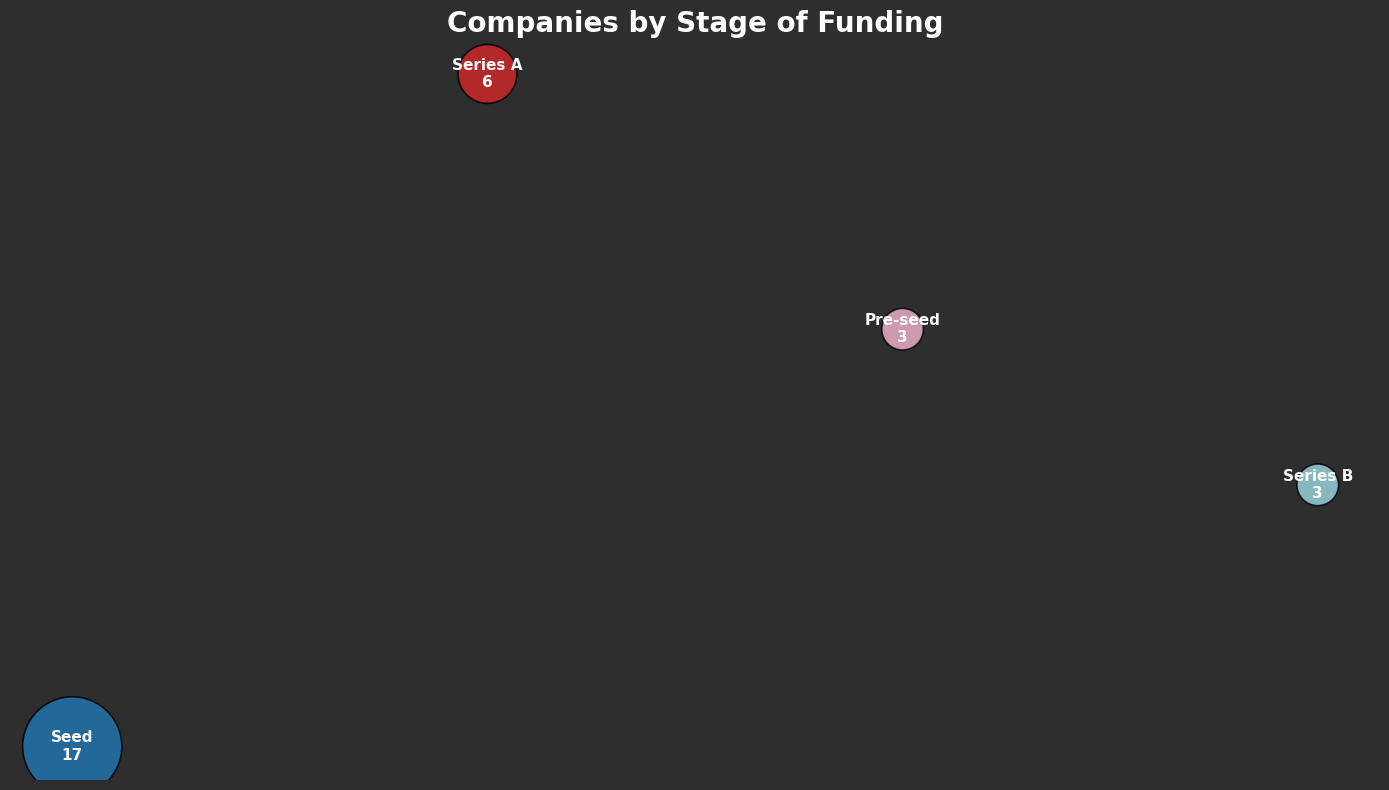

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_excel("Untitled spreadsheet.xlsx")

# Strip extra spaces from column names
df.columns = df.columns.str.strip()

# Select the funding stage column
funding_col = "41. What stage of funding are you in?"

# Count the number of companies at each funding stage
funding_counts = df[funding_col].value_counts()

# Create positions for clusters
np.random.seed(42)
x_positions = np.arange(len(funding_counts))
y_positions = np.random.uniform(0.8, 1.2, size=len(funding_counts))

# Bubble sizes proportional to count
sizes = funding_counts.values * 300  # adjust multiplier for better visuals

# Choose colors from a colormap
colors = plt.cm.tab20(np.linspace(0, 1, len(funding_counts)))

# Plot bubbles with dark background
fig, ax = plt.subplots(figsize=(14,8))
fig.patch.set_facecolor('#2E2E2E')  # figure background
ax.set_facecolor('#2E2E2E')         # axes background

scatter = ax.scatter(
    x_positions, 
    y_positions, 
    s=sizes, 
    color=colors, 
    alpha=0.8, 
    edgecolors='black', 
    linewidth=1.2
)

# Annotate bubbles with stage and count
for i, (stage, count) in enumerate(zip(funding_counts.index, funding_counts.values)):
    ax.text(x_positions[i], y_positions[i], f"{stage}\n{count}", 
            ha='center', va='center', fontsize=11, weight='bold', color='white')

# Add title
ax.set_title("Companies by Stage of Funding", fontsize=20, weight='bold', color='white')

# Remove axes for clean look
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()


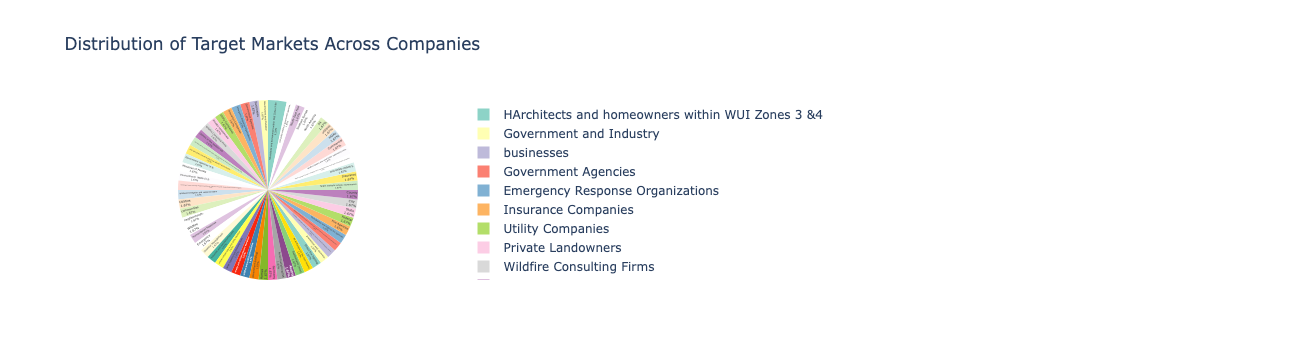

In [5]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_excel("Untitled spreadsheet.xlsx")

# Strip extra spaces from column names
df.columns = df.columns.str.strip()

# Select relevant column
target_col = "33. Who are the target markets that you are serving?"
data = df[target_col].dropna()

# Split multi-select entries and count
market_counts = data.str.split(',').explode().str.strip().value_counts().reset_index()
market_counts.columns = ['Market', 'Count']

# Create interactive pie chart
fig = px.pie(
    market_counts, 
    names='Market', 
    values='Count', 
    hover_data=['Count'], 
    title="Distribution of Target Markets Across Companies",
    color_discrete_sequence=px.colors.qualitative.Set3  # nice palette
)

# Show figure
fig.update_traces(textposition='inside', textinfo='percent+label')  # show percent and label inside slices
fig.show()


/tmp/ipykernel_6558/3014931928.py:41: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.



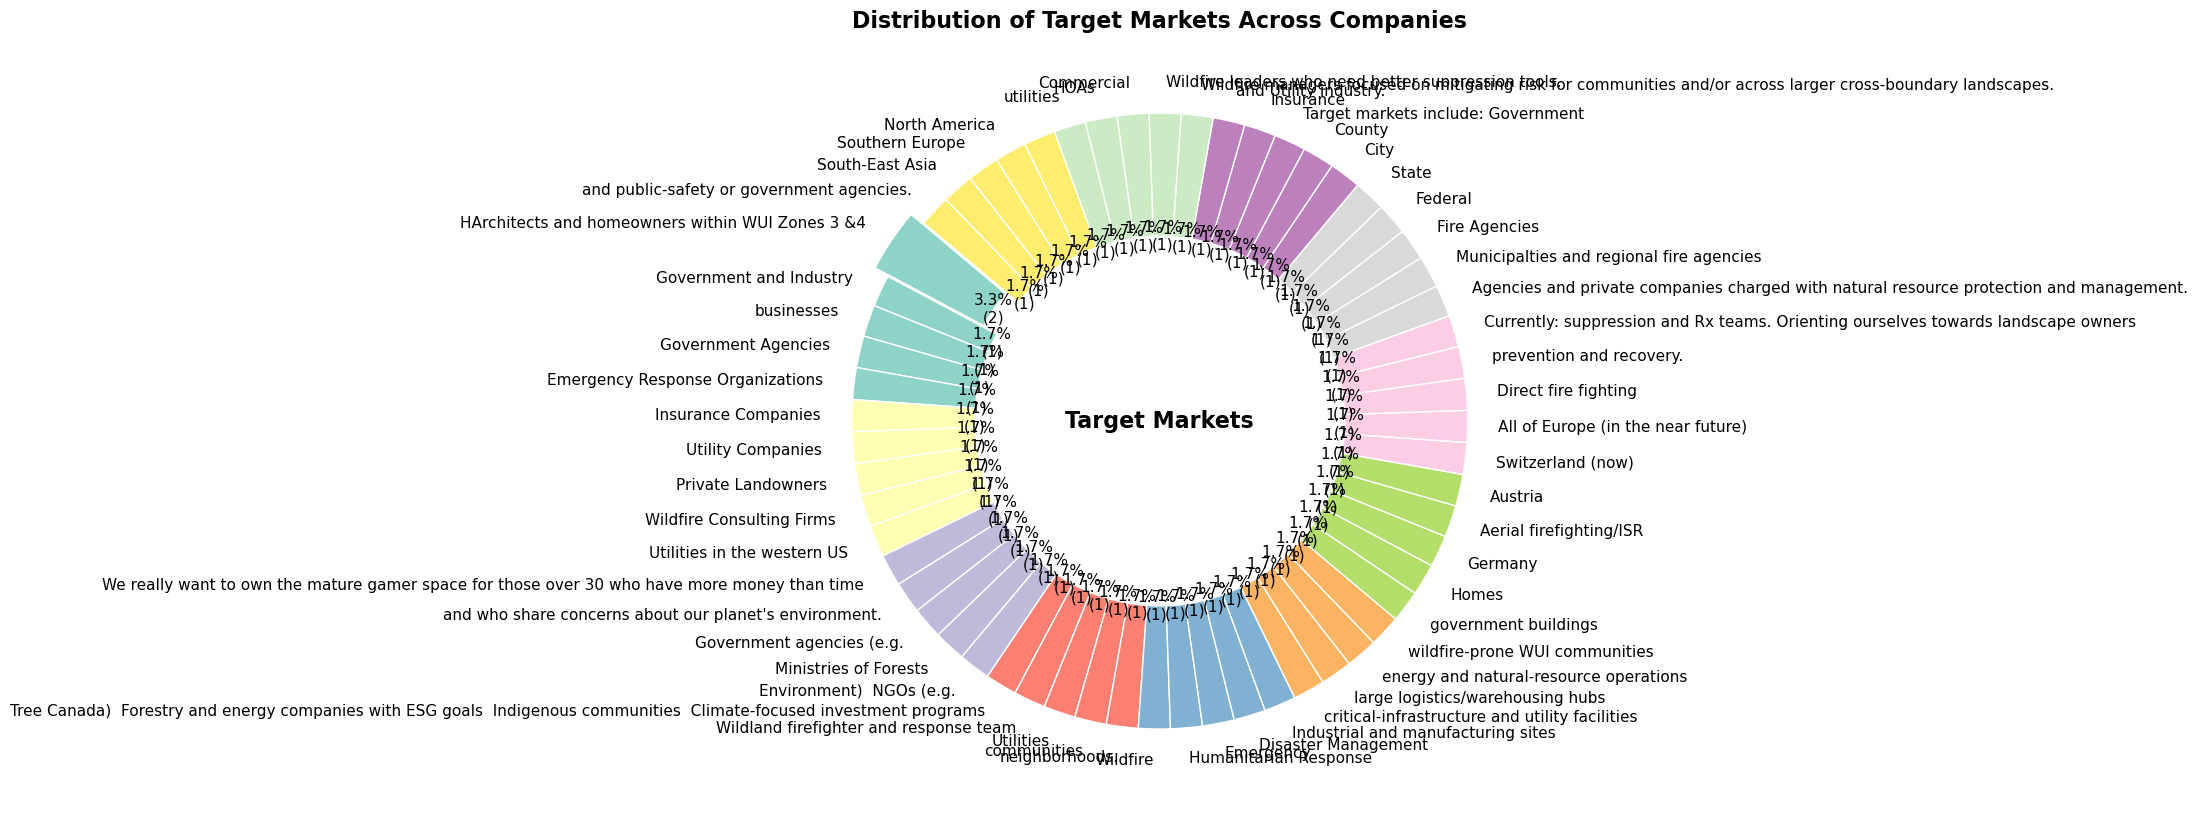

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_excel("Untitled spreadsheet.xlsx")

# Strip extra spaces from column names
df.columns = df.columns.str.strip()

# Select relevant column
target_col = "33. Who are the target markets that you are serving?"
data = df[target_col].dropna()

# Split multi-select entries and count
market_counts = data.str.split(',').explode().str.strip().value_counts()

# Donut chart settings
plt.figure(figsize=(10,10))
colors = plt.cm.Set3(np.linspace(0, 1, len(market_counts)))  # nice qualitative palette
explode = [0.05 if i == 0 else 0 for i in range(len(market_counts))]  # slightly explode largest slice

# Create donut chart
wedges, texts, autotexts = plt.pie(
    market_counts, 
    labels=market_counts.index, 
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct*sum(market_counts)/100))})",  # show % + count
    startangle=140, 
    colors=colors, 
    explode=explode,
    wedgeprops={'width':0.4, 'edgecolor':'white'},  # width <1 creates donut
    textprops={'fontsize':11}
)

# Center text
plt.text(0, 0, 'Target Markets', ha='center', va='center', fontsize=16, weight='bold')

# Title
plt.title("Distribution of Target Markets Across Companies", fontsize=16, weight='bold')

plt.tight_layout()
plt.show()


/tmp/ipykernel_6558/442657042.py:43: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.



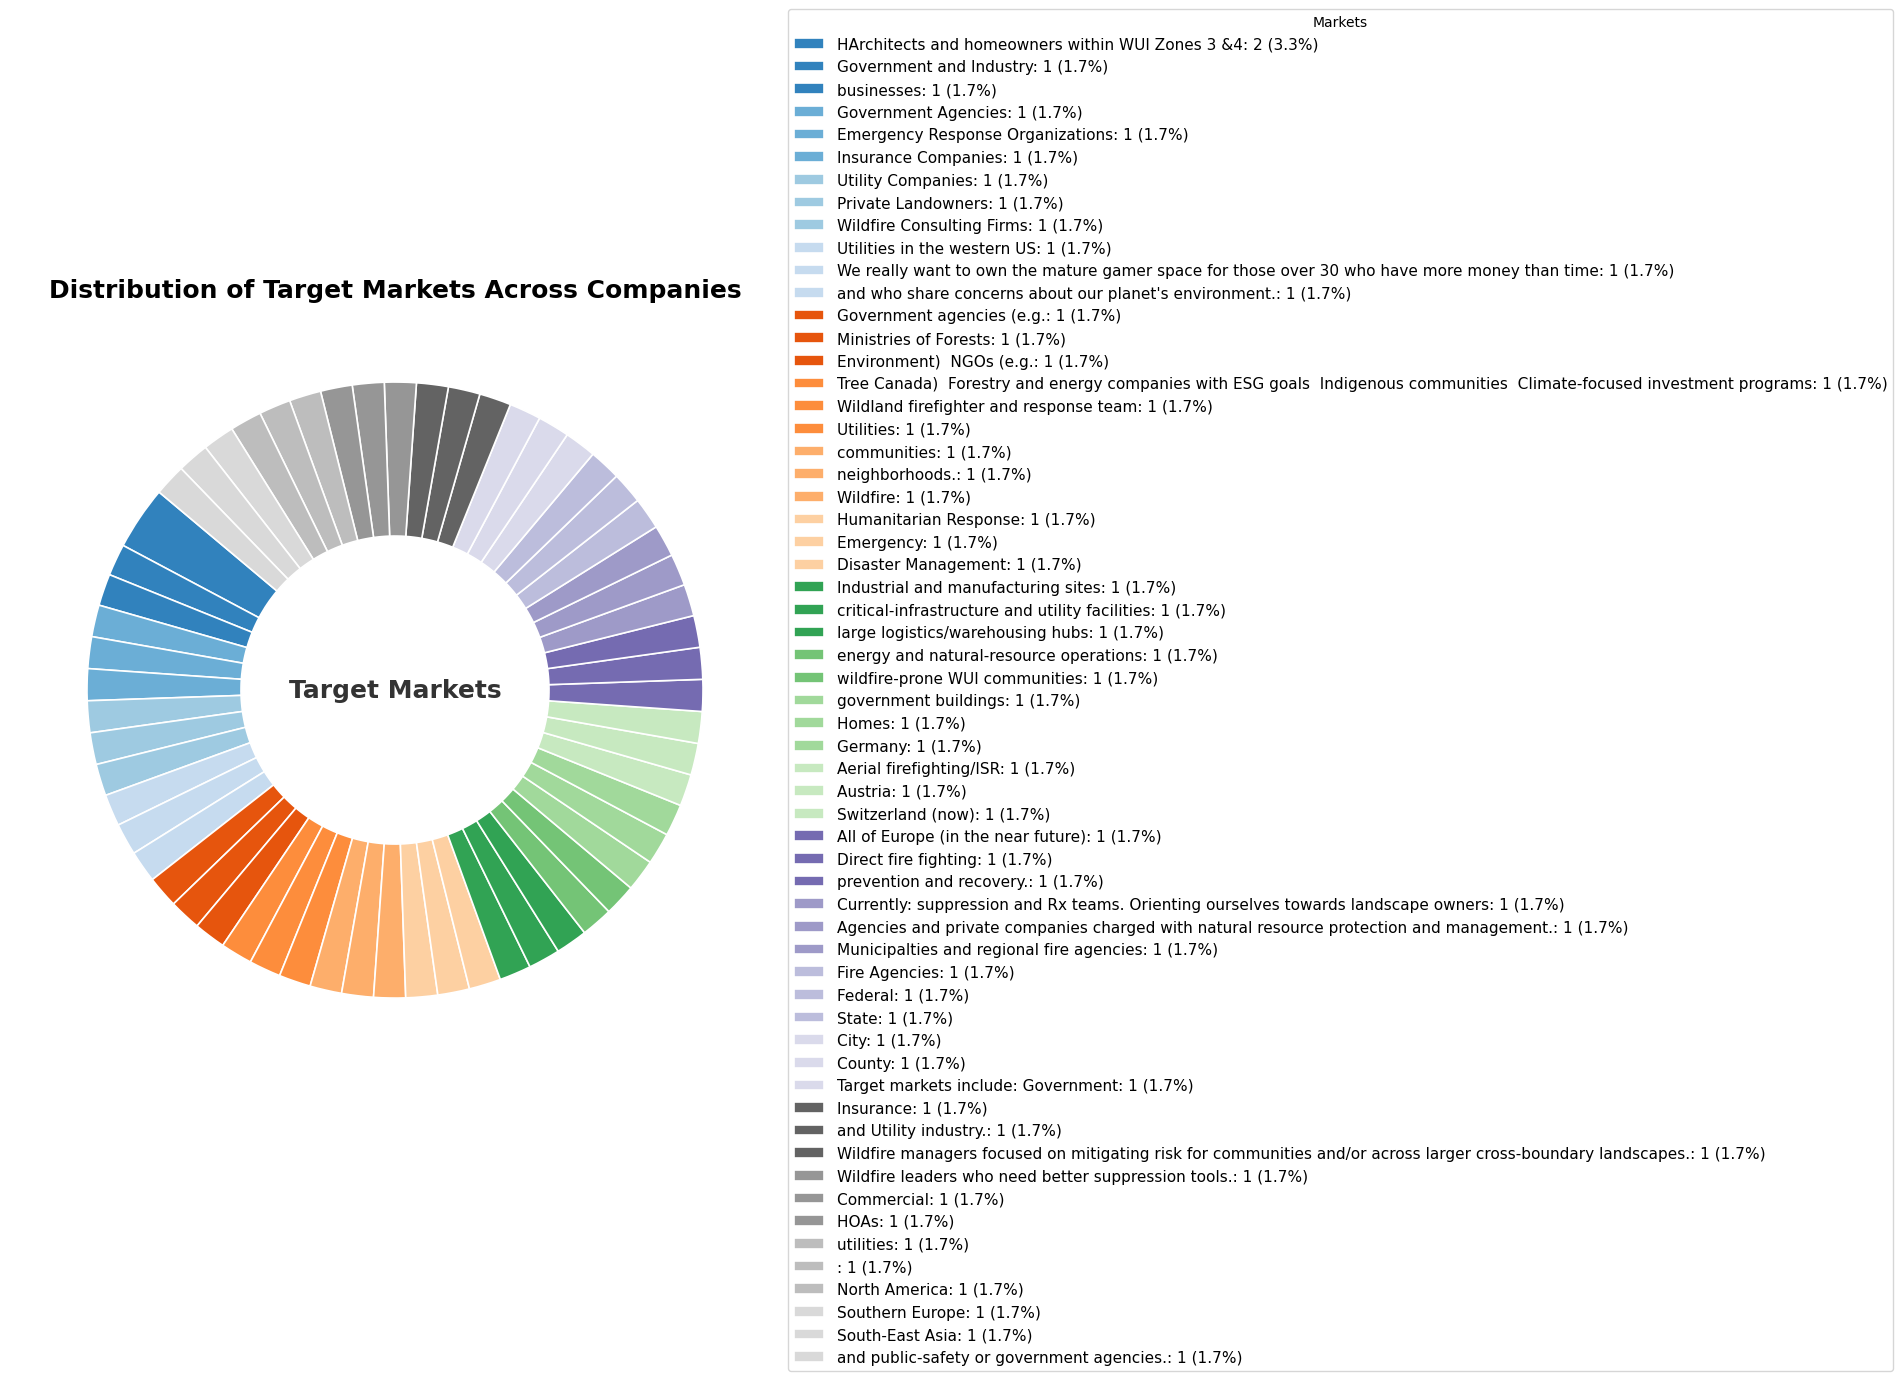

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_excel("Untitled spreadsheet.xlsx")

# Strip extra spaces from column names
df.columns = df.columns.str.strip()

# Select relevant column
target_col = "33. Who are the target markets that you are serving?"
data = df[target_col].dropna()

# Split multi-select entries and count
market_counts = data.str.split(',').explode().str.strip().value_counts()

# Donut chart settings
plt.figure(figsize=(10,10))

# Use a soft qualitative colormap for clarity
colors = plt.cm.tab20c(np.linspace(0, 1, len(market_counts)))

# Create donut chart with a larger hole
wedges, _ = plt.pie(
    market_counts,
    startangle=140,
    colors=colors,
    wedgeprops={'width':0.5, 'edgecolor':'white', 'linewidth':1.2}
)

# Center text
plt.text(0, 0, 'Target Markets', ha='center', va='center', fontsize=18, weight='bold', color='#333333')

# Add title
plt.title("Distribution of Target Markets Across Companies", fontsize=18, weight='bold')

# Add legend with counts and percentages
legend_labels = [f"{label}: {count} ({count/sum(market_counts)*100:.1f}%)" 
                 for label, count in zip(market_counts.index, market_counts.values)]
plt.legend(wedges, legend_labels, title="Markets", bbox_to_anchor=(1, 0.5), loc="center left", fontsize=11)

plt.tight_layout()
plt.show()


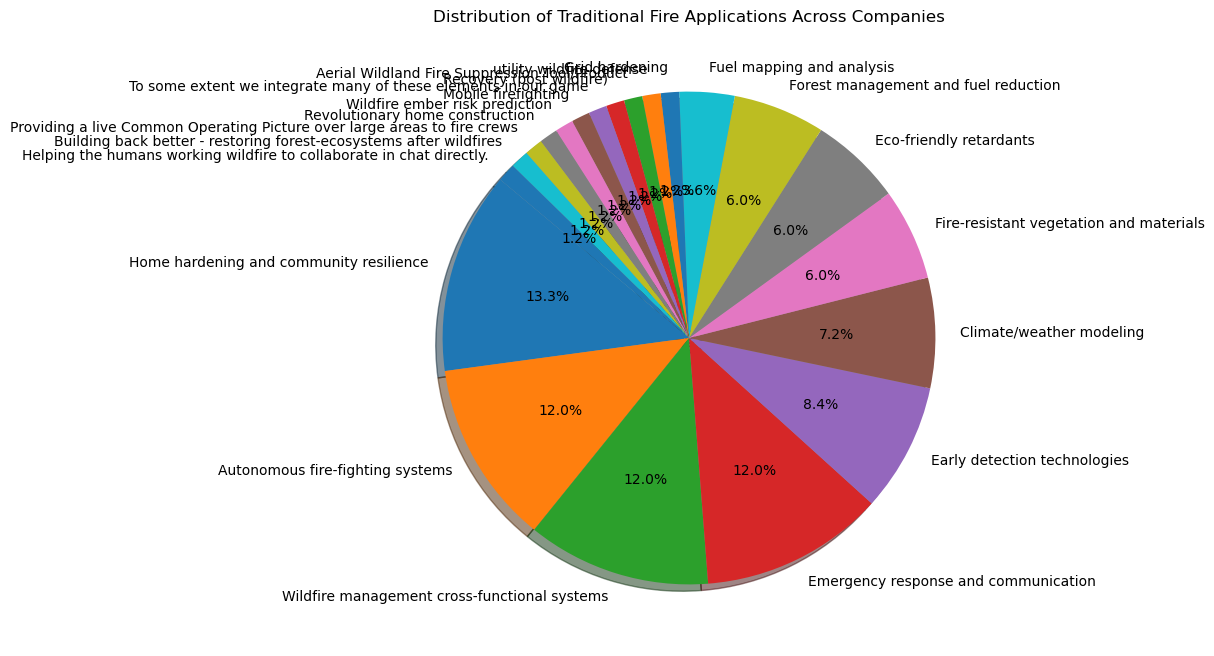

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("Untitled spreadsheet.xlsx")

# Column for Traditional Fire Applications
fire_col = "28. What Fire Application Type(s) -  Traditional Fire Applications (Select all that apply)"

# Drop empty rows
data = df[fire_col].dropna()

# Split multi-select entries, explode into single rows, strip extra spaces, count occurrences
fire_counts = data.str.split(',').explode().str.strip().value_counts()

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(fire_counts, labels=fire_counts.index, autopct='%1.1f%%', startangle=140, shadow=True)
plt.title("Distribution of Traditional Fire Applications Across Companies")
plt.show()


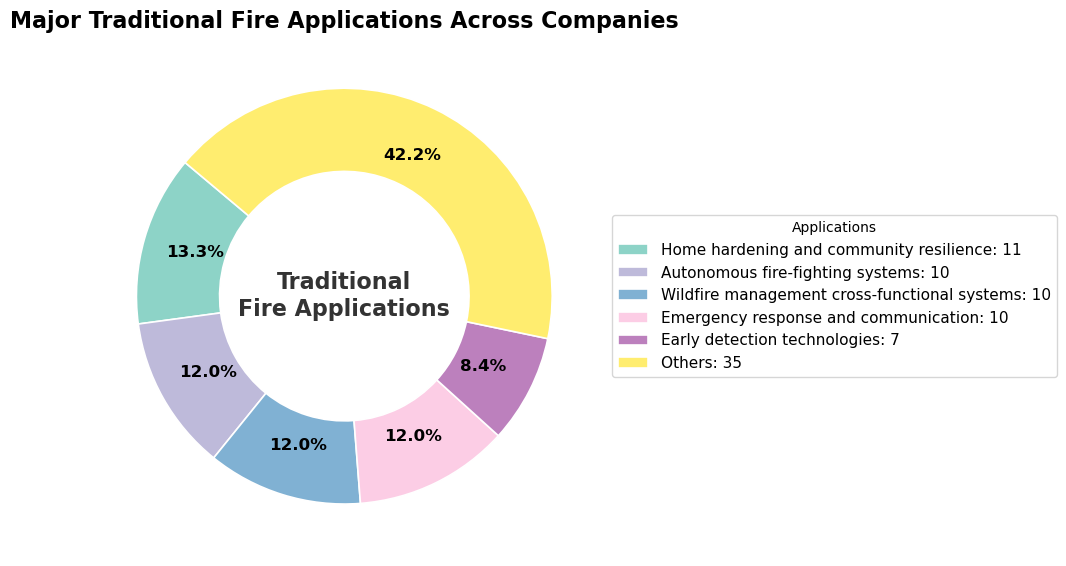

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_excel("Untitled spreadsheet.xlsx")

# Column for Traditional Fire Applications
fire_col = "28. What Fire Application Type(s) -  Traditional Fire Applications (Select all that apply)"

# Drop empty rows
data = df[fire_col].dropna()

# Split multi-select entries, explode into single rows, strip extra spaces, count occurrences
fire_counts = data.str.split(',').explode().str.strip().value_counts()

# Show only the top N categories
top_n = 5
major_counts = fire_counts[:top_n]
others_count = fire_counts[top_n:].sum()

# Add "Others" category if there are remaining
if others_count > 0:
    major_counts['Others'] = others_count

# Donut chart settings
plt.figure(figsize=(10,10))
colors = plt.cm.Set3(np.linspace(0, 1, len(major_counts)))

# Create donut chart with percentages inside
wedges, texts, autotexts = plt.pie(
    major_counts,
    startangle=140,
    colors=colors,
    wedgeprops={'width':0.4, 'edgecolor':'white', 'linewidth':1.2},
    autopct='%1.1f%%',   # show percentages
    pctdistance=0.75     # distance of percentage from center
)

# Style the autopct text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

# Center text
plt.text(0, 0, 'Traditional\nFire Applications', ha='center', va='center', fontsize=16, weight='bold', color='#333333')

# Title
plt.title("Major Traditional Fire Applications Across Companies", fontsize=16, weight='bold')

# Legend with counts
legend_labels = [f"{label}: {count}" for label, count in zip(major_counts.index, major_counts.values)]
plt.legend(wedges, legend_labels, title="Applications", bbox_to_anchor=(1, 0.5), loc="center left", fontsize=11)

plt.tight_layout()
plt.show()


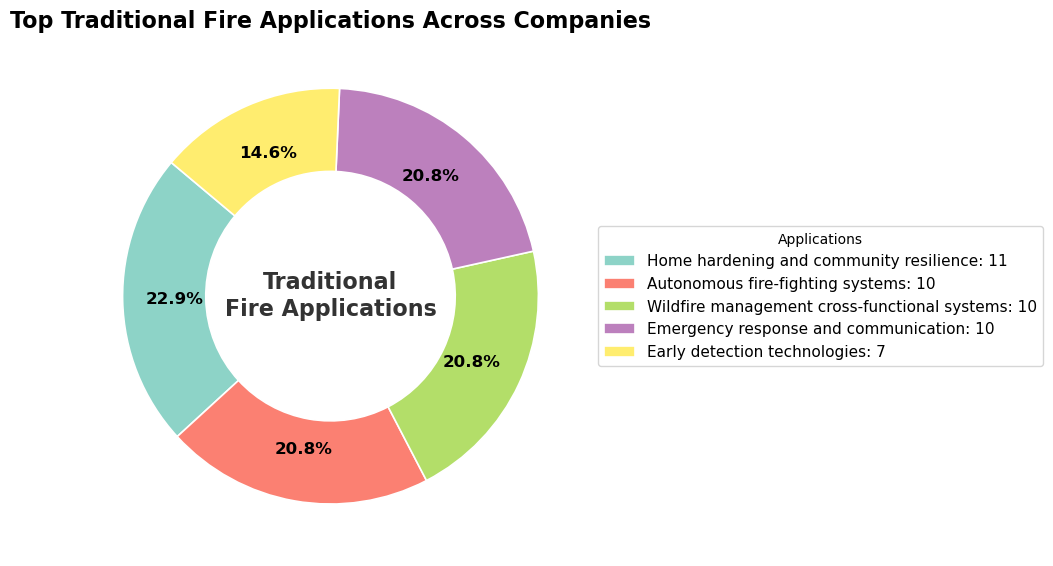

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_excel("Untitled spreadsheet.xlsx")

# Column for Traditional Fire Applications
fire_col = "28. What Fire Application Type(s) -  Traditional Fire Applications (Select all that apply)"

# Drop empty rows
data = df[fire_col].dropna()

# Split multi-select entries, explode into single rows, strip extra spaces, count occurrences
fire_counts = data.str.split(',').explode().str.strip().value_counts()

# Show only the top N categories
top_n = 5
major_counts = fire_counts[:top_n]

# Donut chart settings
plt.figure(figsize=(10,10))
colors = plt.cm.Set3(np.linspace(0, 1, len(major_counts)))

# Create donut chart with percentages inside
wedges, texts, autotexts = plt.pie(
    major_counts,
    startangle=140,
    colors=colors,
    wedgeprops={'width':0.4, 'edgecolor':'white', 'linewidth':1.2},
    autopct='%1.1f%%',
    pctdistance=0.75
)

# Style the autopct text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

# Center text
plt.text(0, 0, 'Traditional\nFire Applications', ha='center', va='center', fontsize=16, weight='bold', color='#333333')

# Title
plt.title("Top Traditional Fire Applications Across Companies", fontsize=16, weight='bold')

# Legend with counts
legend_labels = [f"{label}: {count}" for label, count in zip(major_counts.index, major_counts.values)]
plt.legend(wedges, legend_labels, title="Applications", bbox_to_anchor=(1, 0.5), loc="center left", fontsize=11)

plt.tight_layout()
plt.show()

